In [1]:
import warnings
warnings.filterwarnings("ignore")

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

# Case - Guardian Gestora<br>

### Contexto e desafio:
O objetivo deste case é desenvolver uma análise de uma carteira de crédito estruturado, obtendo visões
analíticas relevantes e calculando métricas de desempenho. A solução deverá ser implementada em Python,
aplicando boas práticas de tratamento, modelagem e visualização de dados.<br><br>
### Etapas:
ETAPA 1 –Distribuição da Carteira<br>
Analise a distribuição dos valores de parcela e valores de aquisição da carteira, considerando os seguintes
agrupamentos:
- Mês de aquisição
- Convênio<br>
(Bônus): Calcule o valor presente do dia 31/01/2026 das parcelas e apresente a distribuição utilizando os mesmos
agrupamentos.

<br>ETAPA 2 –TaxaMédia da Carteira<br>
Calcule a taxa média ponderada da carteira total (pondere pelo valor que achar melhor) e também segmentada
pelos seguintes agrupamentos:
- Mês de aquisição
- Convênio

<br>ETAPA 3 –Inadimplênciada Carteira<br>
Calcule a inadimplência cash da carteira, considerando os seguintes agrupamentos:
- Mês de aquisição
- Convênio
- Mês de vencimento
Obs.: inad_cash = 1 −
valor_pago
valor_a_receber, para as parcelas vencidas (com vencimento antes do dia 31/01/2026).

<br>ETAPA 4 –Identificando onde está o problema<br>
Com base nas análises anteriores, identifique o principal problema da carteira que está impactando a rentabilidade
do fundo e determine quando ele teve início.

# Preparando o material

In [3]:
# Criando a tabela com os dados fornecidos sobre a carteira
csvfile = "carteira.csv"
data = pd.read_csv(csvfile, sep = ';')
data

,id_contrato,mes_aquisicao,id_convenio,mes_vencimento,valor_parcela,valor_aquisicao_parcela,taxa_mensal,data_pagamento,valor_pago
0,1,01/11/2022,1,28/02/2025,780.91,495.74,0.0162,20/02/2025,776.58
1,1,01/11/2022,1,31/03/2025,780.91,487.65,0.0162,NaN,NaN
2,1,01/11/2022,1,30/04/2025,780.91,479.42,0.0162,22/04/2025,776.56
3,1,01/11/2022,1,31/05/2025,780.91,471.60,0.0162,20/05/2025,775.32
4,1,01/11/2022,1,30/06/2025,780.91,463.64,0.0162,18/06/2025,775.93
...,...,...,...,...,...,...,...,...,...
345913,4000,01/07/2023,11,30/04/2031,408.01,66.24,0.0193,NaN,NaN
345914,4000,01/07/2023,11,31/05/2031,408.01,64.98,0.0192,NaN,NaN
345915,4000,01/07/2023,11,30/06/2031,408.01,63.69,0.0193,NaN,NaN
345916,4000,01/07/2023,11,31/07/2031,408.01,62.48,0.0193,NaN,NaN


In [4]:
# O type das datas estao como 'object', passando por uma leve formatacao para garantir que estao em formato de data
data['mes_aquisicao'] = pd.to_datetime(
    data['mes_aquisicao'],
    format='%d/%m/%Y',
    errors='coerce'
).dt.strftime('%Y-%m-%d')

data['mes_vencimento'] = pd.to_datetime(
    data['mes_vencimento'],
    format='%d/%m/%Y',
    errors='coerce'
).dt.strftime('%Y-%m-%d')

data['data_pagamento'] = pd.to_datetime(
    data['data_pagamento'],
    format='%d/%m/%Y',
    errors='coerce'
).dt.strftime('%Y-%m-%d')

In [5]:
# Show, agora que os types estao certinhos da para comecar
display(data.head(15))

,id_contrato,mes_aquisicao,id_convenio,mes_vencimento,valor_parcela,valor_aquisicao_parcela,taxa_mensal,data_pagamento,valor_pago
0,1,2022-11-01,1,2025-02-28,780.91,495.74,0.0162,2025-02-20,776.58
1,1,2022-11-01,1,2025-03-31,780.91,487.65,0.0162,NaN,NaN
2,1,2022-11-01,1,2025-04-30,780.91,479.42,0.0162,2025-04-22,776.56
3,1,2022-11-01,1,2025-05-31,780.91,471.60,0.0162,2025-05-20,775.32
4,1,2022-11-01,1,2025-06-30,780.91,463.64,0.0162,2025-06-18,775.93
5,1,2022-11-01,1,2025-07-31,780.91,456.07,0.0162,2025-07-30,779.66
6,1,2022-11-01,1,2025-08-31,780.91,448.38,0.0162,2025-08-20,775.33
7,1,2022-11-01,1,2025-09-30,780.91,440.81,0.0163,2025-09-22,776.57
8,1,2022-11-01,1,2025-10-31,780.91,433.61,0.0162,2025-10-15,773.49
9,1,2022-11-01,1,2025-11-30,780.91,426.30,0.0163,NaN,NaN


# Etapa 1

### Mês de Aquisição

In [6]:
# Criando tabela para visualizacao da distribuicao por mes de aquisicao
dist_mes = data.groupby('mes_aquisicao', as_index = False).agg({'valor_aquisicao_parcela' : 'sum',
                                                                'valor_parcela' : 'sum'}).sort_values('mes_aquisicao')
dist_mes

,mes_aquisicao,valor_aquisicao_parcela,valor_parcela
0,2022-10-01,719693.95,1755289.80
1,2022-11-01,2169737.12,4987109.32
2,2022-12-01,2525206.92,5813295.97
3,2023-01-01,5529929.24,12692599.60
4,2023-02-01,4456054.22,10034672.32
5,2023-03-01,2500316.97,5865775.20
6,2023-04-01,3059677.29,6669120.66
7,2023-05-01,5428871.37,12308529.46
8,2023-06-01,1049745.22,2254643.24
9,2023-07-01,457333.33,973507.08


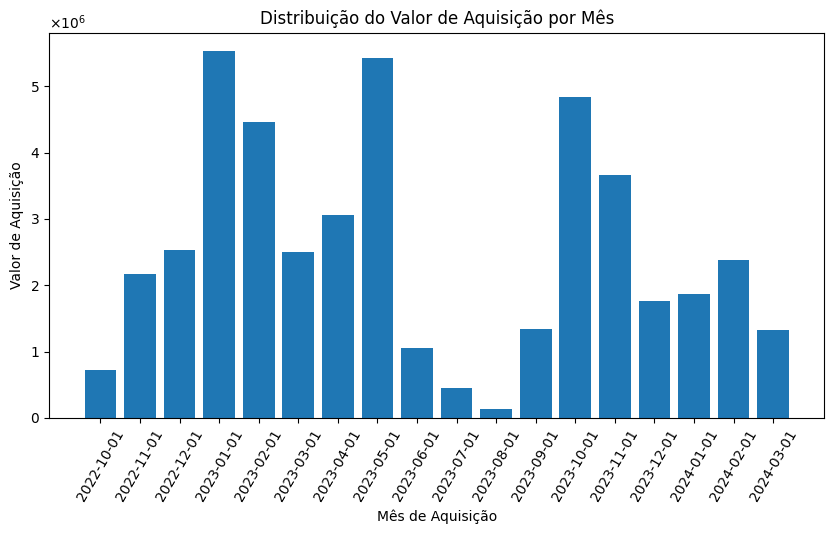

In [8]:
plt.figure(figsize=(10,5))
plt.bar(dist_mes["mes_aquisicao"], dist_mes["valor_aquisicao_parcela"])

plt.title("Distribuição do Valor de Aquisição por Mês")
plt.xlabel("Mês de Aquisição")
plt.ticklabel_format(axis='y', scilimits=(4, 6), useMathText = True)
plt.ylabel("Valor de Aquisição")
plt.xticks(dist_mes["mes_aquisicao"], rotation=60)

plt.show()

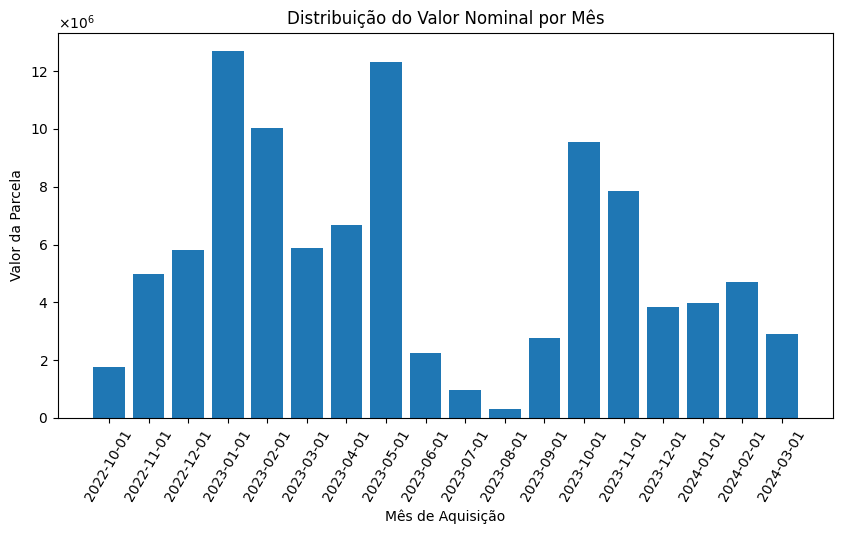

In [48]:
plt.figure(figsize=(10,5))
ax1 = plt.bar(dist_mes["mes_aquisicao"], dist_mes["valor_parcela"])

plt.title("Distribuição do Valor Nominal por Mês")
plt.xlabel("Mês de Aquisição")
plt.ticklabel_format(axis = 'y', scilimits = (6, 6), useMathText = True)
plt.ylabel("Valor da Parcela")
plt.xticks(rotation = 60)

plt.show()

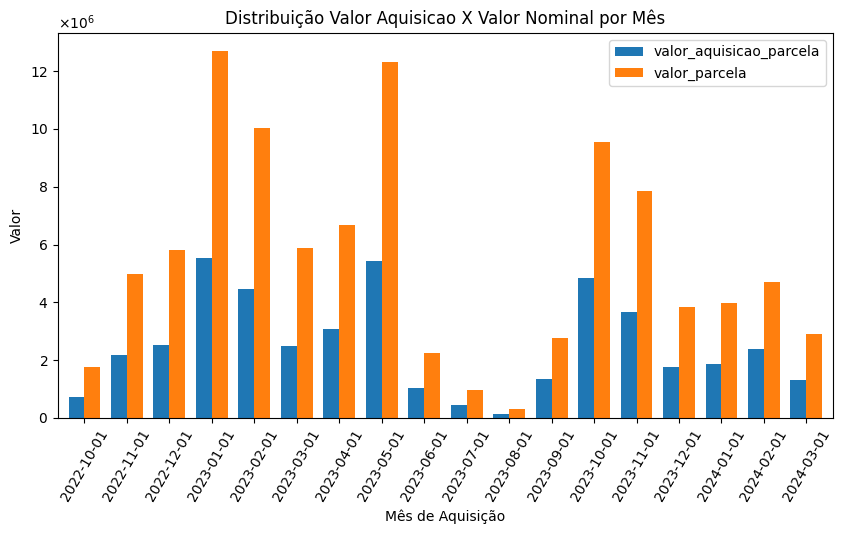

In [10]:
ax = dist_mes.set_index("mes_aquisicao").plot(kind = "bar", figsize = (10,5), width = 0.75)

ax.set_title("Distribuição Valor Aquisicao X Valor Nominal por Mês")
ax.set_xlabel("Mês de Aquisição", )
ax.set_ylabel("Valor")
plt.ticklabel_format(axis = 'y', scilimits = (6, 6), useMathText = True)
plt.xticks(rotation = 60)

plt.show()

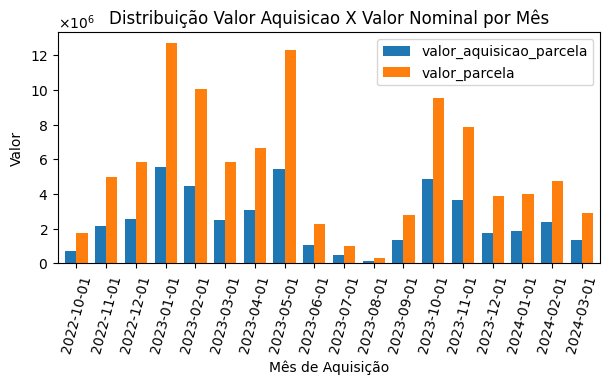

In [11]:
# Plot para colocar no slide
ax = dist_mes.set_index("mes_aquisicao").plot(kind = "bar", figsize = (7,3), width = 0.75)

ax.set_title("Distribuição Valor Aquisicao X Valor Nominal por Mês")
ax.set_xlabel("Mês de Aquisição", )
ax.set_ylabel("Valor")
plt.ticklabel_format(axis = 'y', scilimits = (6, 6), useMathText = True)
plt.xticks(rotation = 75)

plt.show()

### Convênio

In [86]:
# Criando tabela para visualizacao da distribuicao por convenio
dist_convenio = data.groupby("id_convenio", as_index = False).agg({"valor_aquisicao_parcela" : "sum",
                                            "valor_parcela" : "sum"}).sort_values("valor_aquisicao_parcela", ascending = False)
dist_convenio

,id_convenio,valor_aquisicao_parcela,valor_parcela
1,2,12417751.56,28110098.63
2,3,11613074.28,26430458.75
3,4,5909395.30,13204815.21
10,11,4448674.58,9053175.90
7,8,3619917.04,8644736.76
8,9,2560201.92,5292160.92
9,10,2503432.39,3619564.66
0,1,1841803.52,4294289.19
4,5,251851.26,544126.86
6,7,36116.69,69254.86


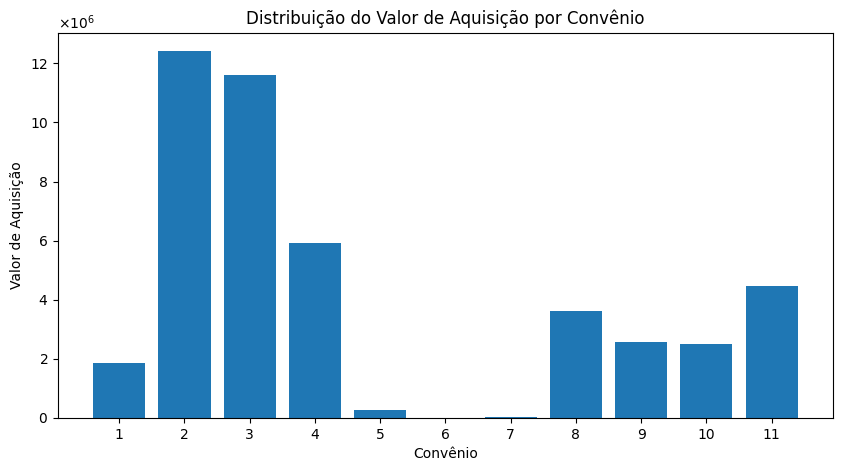

In [87]:
# Criando os plots para melhor entendimento dos dados
plt.figure(figsize=(10,5))
plt.bar(dist_convenio["id_convenio"], dist_convenio["valor_aquisicao_parcela"])

plt.title("Distribuição do Valor de Aquisição por Convênio")
plt.xlabel("Convênio")
plt.ylabel("Valor de Aquisição")
plt.ticklabel_format(axis = 'y', scilimits = (6, 6), useMathText = True)
plt.xticks(dist_convenio["id_convenio"])

plt.show()

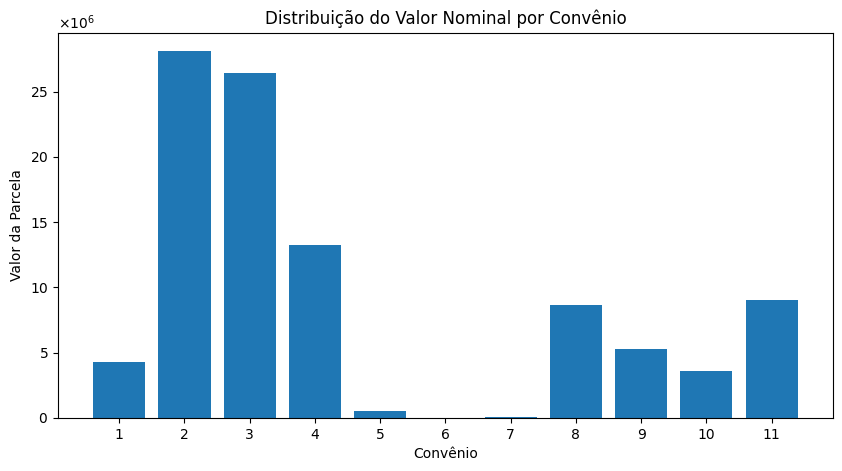

In [83]:
plt.figure(figsize=(10,5))
plt.bar(dist_convenio["id_convenio"], dist_convenio["valor_parcela"])

plt.title("Distribuição do Valor Nominal por Convênio")
plt.xlabel("Convênio")
plt.ylabel("Valor da Parcela")
plt.ticklabel_format(axis = 'y', scilimits = (6, 6), useMathText = True)
plt.xticks(dist_convenio["id_convenio"])

plt.show()

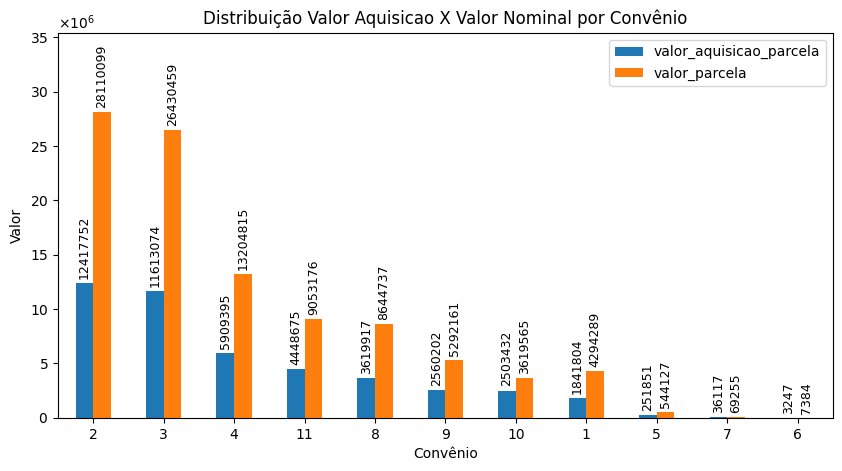

In [15]:
# Nesse plot, em especifico, vou colocar os valores aparentes acima das barras por conta de uma diferenca grande entre os dados
ax = dist_convenio.set_index("id_convenio").plot(kind = "bar", figsize = (10,5))

ax.set_title("Distribuição Valor Aquisicao X Valor Nominal por Convênio")
ax.set_xlabel("Convênio")
ax.set_ylabel("Valor")
plt.ticklabel_format(axis = 'y', scilimits = (6, 6), useMathText = True)
plt.xticks(rotation = 0)

for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.0f', rotation = 90, fontsize = 9)

ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

plt.show()

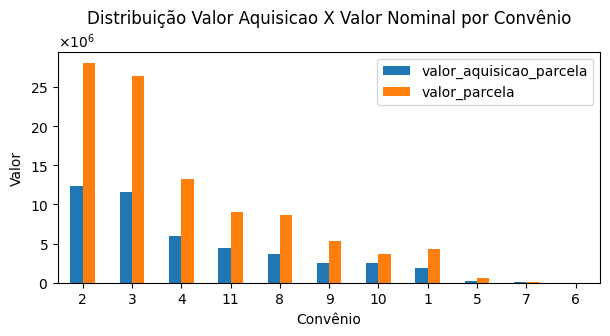

In [16]:
# Plot para colocar no slide
ax = dist_convenio.set_index("id_convenio").plot(kind = "bar", figsize = (7,3))

ax.set_title("Distribuição Valor Aquisicao X Valor Nominal por Convênio")
ax.set_xlabel("Convênio")
ax.set_ylabel("Valor")
plt.ticklabel_format(axis = 'y', scilimits = (6, 6), useMathText = True)
plt.xticks(rotation = 0)

#for container in ax.containers:
    #ax.bar_label(container, padding=3, fmt='%.0f', rotation = 90, fontsize = 9)

#ax.set_ylim(0, ax.get_ylim()[1] * 1.35)

plt.show()

### Bônus

In [17]:
# Antes de começar a calcular o VP, vou calcular quantos meses faltam entre 31/01/2026 e os meses de vencimento
dia_base = pd.Timestamp("2026-01-31")
data["mes_vencimento"] = pd.to_datetime(
    data["mes_vencimento"],
    errors="coerce"
)
data["n_meses"] = (
    (data["mes_vencimento"].dt.year - dia_base.year) * 12 +
    (data["mes_vencimento"].dt.month - dia_base.month)
)

# Considerando apenas parcelas futuras
data["n_meses"] = data["n_meses"].clip(lower=0)

data

,id_contrato,mes_aquisicao,id_convenio,mes_vencimento,valor_parcela,valor_aquisicao_parcela,taxa_mensal,data_pagamento,valor_pago,n_meses
0,1,2022-11-01,1,2025-02-28,780.91,495.74,0.0162,2025-02-20,776.58,0
1,1,2022-11-01,1,2025-03-31,780.91,487.65,0.0162,NaN,NaN,0
2,1,2022-11-01,1,2025-04-30,780.91,479.42,0.0162,2025-04-22,776.56,0
3,1,2022-11-01,1,2025-05-31,780.91,471.60,0.0162,2025-05-20,775.32,0
4,1,2022-11-01,1,2025-06-30,780.91,463.64,0.0162,2025-06-18,775.93,0
...,...,...,...,...,...,...,...,...,...,...
345913,4000,2023-07-01,11,2031-04-30,408.01,66.24,0.0193,NaN,NaN,63
345914,4000,2023-07-01,11,2031-05-31,408.01,64.98,0.0192,NaN,NaN,64
345915,4000,2023-07-01,11,2031-06-30,408.01,63.69,0.0193,NaN,NaN,65
345916,4000,2023-07-01,11,2031-07-31,408.01,62.48,0.0193,NaN,NaN,66


In [18]:
# Aplicando a formula VP
data["valor_presente"] = data["valor_parcela"] / ((1 + data["taxa_mensal"]) ** data["n_meses"])
data

,id_contrato,mes_aquisicao,id_convenio,mes_vencimento,valor_parcela,valor_aquisicao_parcela,taxa_mensal,data_pagamento,valor_pago,n_meses,valor_presente
0,1,2022-11-01,1,2025-02-28,780.91,495.74,0.0162,2025-02-20,776.58,0,780.910000
1,1,2022-11-01,1,2025-03-31,780.91,487.65,0.0162,NaN,NaN,0,780.910000
2,1,2022-11-01,1,2025-04-30,780.91,479.42,0.0162,2025-04-22,776.56,0,780.910000
3,1,2022-11-01,1,2025-05-31,780.91,471.60,0.0162,2025-05-20,775.32,0,780.910000
4,1,2022-11-01,1,2025-06-30,780.91,463.64,0.0162,2025-06-18,775.93,0,780.910000
...,...,...,...,...,...,...,...,...,...,...,...
345913,4000,2023-07-01,11,2031-04-30,408.01,66.24,0.0193,NaN,NaN,63,122.361075
345914,4000,2023-07-01,11,2031-05-31,408.01,64.98,0.0192,NaN,NaN,64,120.800365
345915,4000,2023-07-01,11,2031-06-30,408.01,63.69,0.0193,NaN,NaN,65,117.771236
345916,4000,2023-07-01,11,2031-07-31,408.01,62.48,0.0193,NaN,NaN,66,115.541289


In [19]:
# VP por mes de aquisicao
vp_mes = (
    data.groupby("mes_aquisicao", as_index=False)
      .agg({"valor_presente": "sum"})
      .sort_values("mes_aquisicao")
)
display(vp_mes)

# VP por convenio
vp_convenio = (
    data.groupby("id_convenio", as_index=False)
      .agg({"valor_presente": "sum"})
      .sort_values("valor_presente", ascending=False)
)
vp_convenio

,mes_aquisicao,valor_presente
0,2022-10-01,1.305050e+06
1,2022-11-01,3.738365e+06
2,2022-12-01,4.391587e+06
3,2023-01-01,9.320761e+06
4,2023-02-01,7.383124e+06
5,2023-03-01,4.182399e+06
6,2023-04-01,4.943165e+06
7,2023-05-01,8.742259e+06
8,2023-06-01,1.648104e+06
9,2023-07-01,7.042015e+05


,id_convenio,valor_presente
1,2,1.995923e+07
2,3,1.915379e+07
3,4,9.334085e+06
10,11,6.900469e+06
7,8,5.523240e+06
8,9,3.617393e+06
9,10,3.389070e+06
0,1,3.163764e+06
4,5,3.892094e+05
6,7,5.270603e+04


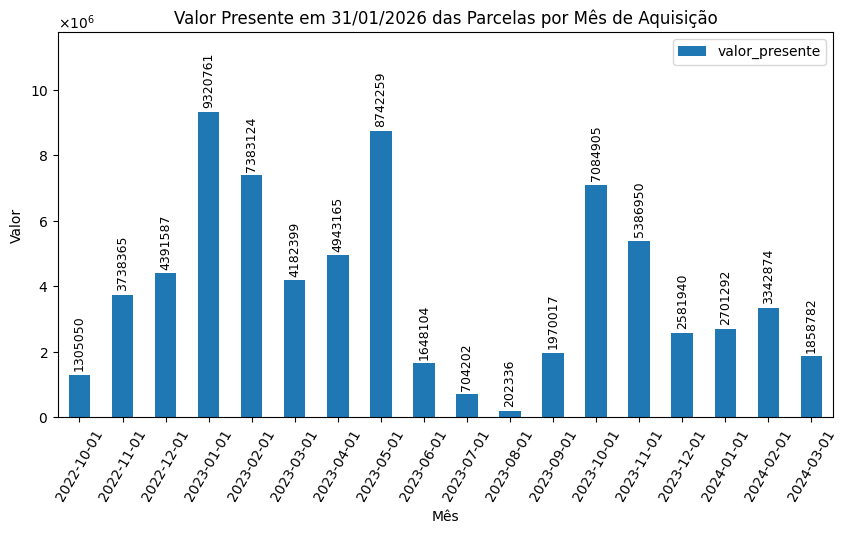

In [20]:
ax = vp_mes.set_index("mes_aquisicao").plot(kind = "bar", figsize = (10,5))

ax.set_title("Valor Presente em 31/01/2026 das Parcelas por Mês de Aquisição")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor")
plt.ticklabel_format(axis = 'y', scilimits = (6, 6), useMathText = True)
plt.xticks(rotation = 60)

for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.0f', rotation = 90, fontsize = 9)

ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
plt.show()

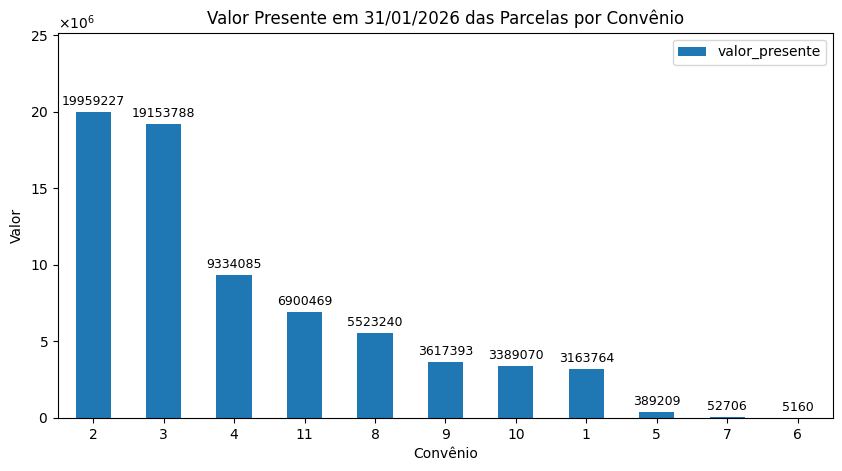

In [22]:
ax = vp_convenio.set_index("id_convenio").plot(kind = "bar", figsize = (10,5))

ax.set_title("Valor Presente em 31/01/2026 das Parcelas por Convênio")
ax.set_xlabel("Convênio")
ax.set_ylabel("Valor")
plt.ticklabel_format(axis = 'y', scilimits = (6, 6), useMathText = True)
plt.xticks(rotation = 0)

for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.0f', rotation = 0, fontsize = 9)

ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

plt.show()

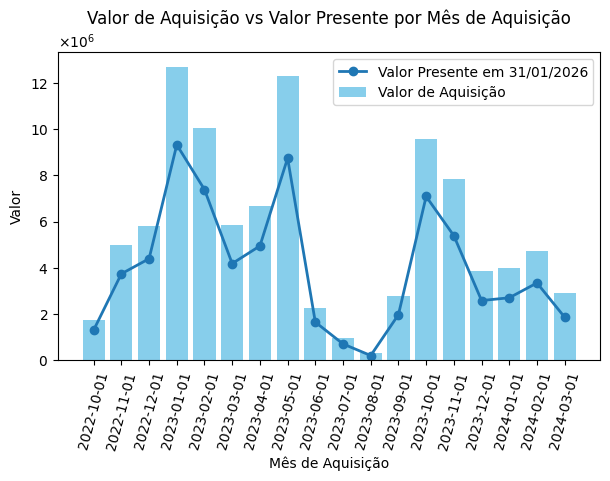

In [95]:
# Plot para colocar no slide
fig, ax = plt.subplots(figsize=(7,4))

# Valor de aquisicao
ax.bar(
    dist_mes["mes_aquisicao"],
    dist_mes["valor_parcela"],
    label = "Valor de Aquisição",
    color = "skyblue"
)

# VP
ax.plot(
    vp_mes["mes_aquisicao"],
    vp_mes["valor_presente"],
    marker="o",
    linewidth=2,
    label="Valor Presente em 31/01/2026",
)

ax.set_title("Valor de Aquisição vs Valor Presente por Mês de Aquisição")
ax.set_xlabel("Mês de Aquisição")
ax.set_ylabel("Valor")
ax.ticklabel_format(axis='y', scilimits=(6, 6), useMathText=True)
plt.xticks(rotation=75)
ax.legend()

plt.show()

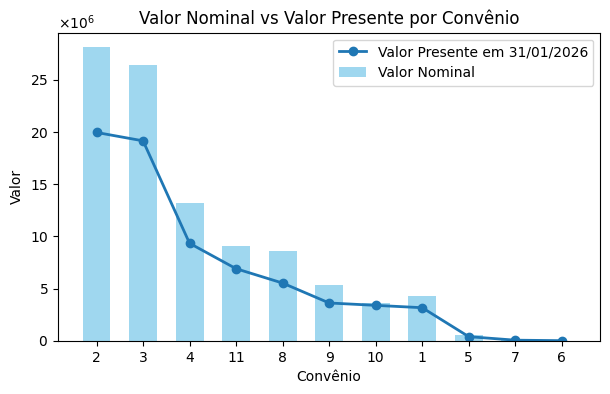

In [96]:
# Plor para colocar no slide

# Junta valor nominal e valor presente no MESMO DataFrame
df = (
    dist_convenio
    .merge(vp_convenio, on="id_convenio", how="inner")
)

# Ordena do MAIOR para o MENOR (use valor_presente ou valor_parcela)
df = df.sort_values(by="valor_presente", ascending=False)

# Define posições no eixo X
x = np.arange(len(df))
largura = 0.6

fig, ax = plt.subplots(figsize=(7, 4))

# precisei usar IA para fazer a parte de cima, pois estava tendo problemas com a organizacao dos dados no grafico

# Valor nominal
ax.bar(
    x,
    df["valor_parcela"],
    width=largura,
    label="Valor Nominal",
    alpha=0.8,
    color = "skyblue"
)

# VP
ax.plot(
    x,
    df["valor_presente"],
    marker="o",
    linewidth=2,
    label="Valor Presente em 31/01/2026"
)

ax.set_title("Valor Nominal vs Valor Presente por Convênio")
ax.set_xlabel("Convênio")
ax.set_ylabel("Valor")
ax.set_xticks(x)
ax.set_xticklabels(df["id_convenio"])
ax.ticklabel_format(axis="y", scilimits=(6, 6), useMathText=True)
ax.legend()

plt.show()


---

# Etapa 2

In [24]:
# Para poder tirar a media da taxa ponderada total da carteira vou utilizar a seguinte formula:
# taxa_media = Σ(taxa_mensal × valor_aquisicao_parcela) / Σ(valor_aquisicao_parcela)
taxa_media_total = (data["taxa_mensal"] * data["valor_aquisicao_parcela"]).sum() / data["valor_aquisicao_parcela"].sum()

taxa_media_total

np.float64(0.018361637533074803)

In [25]:
# Show de bola, podemos agora tirar a taxa media por mes de aquisicao
numerador = (
    data["taxa_mensal"]
    .mul(data["valor_aquisicao_parcela"])
    .groupby(data["mes_aquisicao"])
    .sum()
)

denominador = (
    data["valor_aquisicao_parcela"]
    .groupby(data["mes_aquisicao"])
    .sum()
)

taxa_mes = (
    (numerador / denominador)
      .reset_index(name="taxa_media_ponderada")
      .sort_values("mes_aquisicao")
)

taxa_mes

,mes_aquisicao,taxa_media_ponderada
0,2022-10-01,0.020320
1,2022-11-01,0.017704
2,2022-12-01,0.019802
3,2023-01-01,0.018724
4,2023-02-01,0.018895
5,2023-03-01,0.019109
6,2023-04-01,0.018983
7,2023-05-01,0.018671
8,2023-06-01,0.018967
9,2023-07-01,0.018774


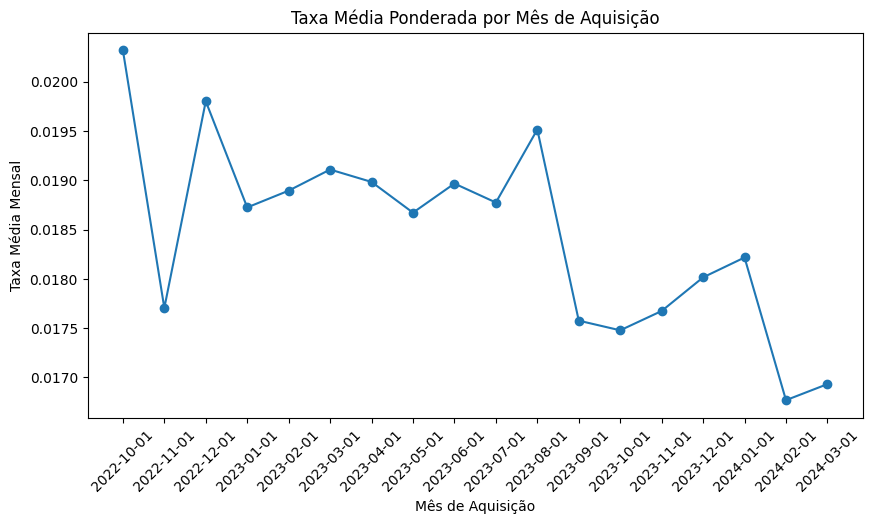

In [26]:
# Vamos plotar o grafico
plt.figure(figsize=(10,5))
plt.plot(taxa_mes["mes_aquisicao"],taxa_mes["taxa_media_ponderada"], marker="o")

plt.title("Taxa Média Ponderada por Mês de Aquisição")
plt.xlabel("Mês de Aquisição")
plt.ylabel("Taxa Média Mensal")
plt.xticks(rotation=45)

plt.show()

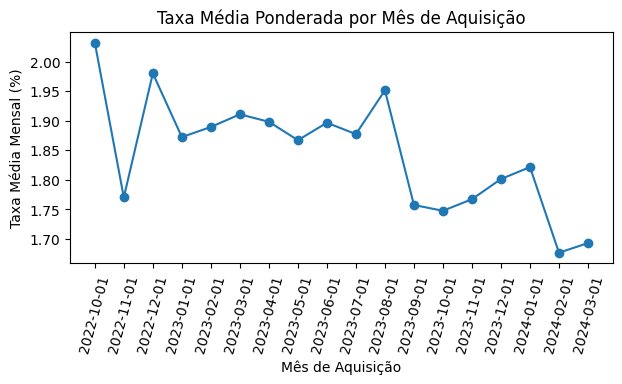

In [27]:
# Plot para colocar no slide
plt.figure(figsize=(7,3))
plt.plot(taxa_mes["mes_aquisicao"],taxa_mes["taxa_media_ponderada"] * 100, marker="o")

plt.title("Taxa Média Ponderada por Mês de Aquisição")
plt.xlabel("Mês de Aquisição")
plt.ylabel("Taxa Média Mensal (%)")
plt.xticks(rotation=75)

plt.show()

In [28]:
# Agora vamos tirar a taxa media por convenio
numerador = (
    data["taxa_mensal"]
    .mul(data["valor_aquisicao_parcela"])
    .groupby(data["id_convenio"])
    .sum()
)

denominador = (
    data["valor_aquisicao_parcela"]
    .groupby(data["id_convenio"])
    .sum()
)

taxa_convenio = (
    (numerador / denominador)
    .reset_index(name="taxa_media_ponderada")
    .sort_values("taxa_media_ponderada", ascending=False)
)

taxa_convenio

,id_convenio,taxa_media_ponderada
2,3,0.019007
3,4,0.018572
1,2,0.018516
9,10,0.018424
5,6,0.018350
4,5,0.018220
7,8,0.018169
10,11,0.017860
6,7,0.017111
0,1,0.017034


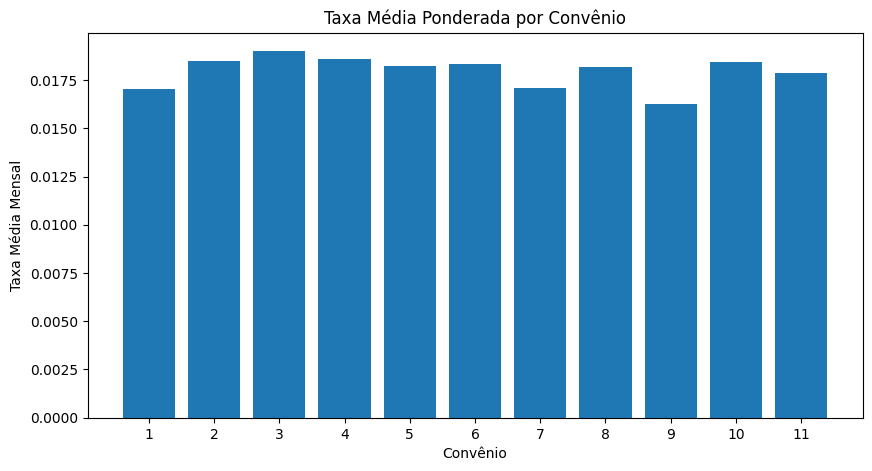

In [29]:
# Vamos plotar esse tambem
plt.figure(figsize=(10,5))
plt.bar(taxa_convenio["id_convenio"],taxa_convenio["taxa_media_ponderada"])

plt.title("Taxa Média Ponderada por Convênio")
plt.xlabel("Convênio")
plt.xticks(taxa_convenio["id_convenio"])
plt.ylabel("Taxa Média Mensal")

plt.show()

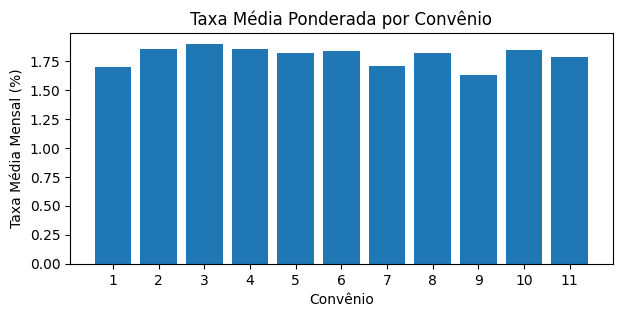

In [30]:
# Plot para colocar no slide
plt.figure(figsize=(7,3))
plt.bar(taxa_convenio["id_convenio"],taxa_convenio["taxa_media_ponderada"] * 100)

plt.title("Taxa Média Ponderada por Convênio")
plt.xlabel("Convênio")
plt.xticks(taxa_convenio["id_convenio"])
plt.ylabel("Taxa Média Mensal (%)")

plt.show()

---

# Etapa 3

In [31]:
# Para poder calcular a inadimplencia da carteira preciso primeiro filtrar somente as parcelas vencidas e a data utilizada para
# consideracao eh 31/01/2026
dia_base = pd.Timestamp("2026-01-31")

df_vencidas = data[data["mes_vencimento"] < dia_base].copy()

# Valor pago nulo vou preencher como 0 e considerar que nao foi pago
df_vencidas["valor_pago"] = df_vencidas["valor_pago"].fillna(0)

df_vencidas

,id_contrato,mes_aquisicao,id_convenio,mes_vencimento,valor_parcela,valor_aquisicao_parcela,taxa_mensal,data_pagamento,valor_pago,n_meses,valor_presente
0,1,2022-11-01,1,2025-02-28,780.91,495.74,0.0162,2025-02-20,776.58,0,780.91
1,1,2022-11-01,1,2025-03-31,780.91,487.65,0.0162,NaN,0.00,0,780.91
2,1,2022-11-01,1,2025-04-30,780.91,479.42,0.0162,2025-04-22,776.56,0,780.91
3,1,2022-11-01,1,2025-05-31,780.91,471.60,0.0162,2025-05-20,775.32,0,780.91
4,1,2022-11-01,1,2025-06-30,780.91,463.64,0.0162,2025-06-18,775.93,0,780.91
...,...,...,...,...,...,...,...,...,...,...,...
345845,4000,2023-07-01,11,2025-08-31,408.01,250.95,0.0186,2025-08-20,407.63,0,408.01
345846,4000,2023-07-01,11,2025-09-30,408.01,245.99,0.0186,2025-09-22,407.63,0,408.01
345847,4000,2023-07-01,11,2025-10-31,408.01,241.29,0.0186,2025-10-15,406.49,0,408.01
345848,4000,2023-07-01,11,2025-11-30,408.01,236.52,0.0187,2025-11-19,407.25,0,408.01


In [32]:
# Calculando inadimplencia da carteira total
inad_cash_total = 1 - (df_vencidas["valor_pago"].sum() / df_vencidas["valor_parcela"].sum())

inad_cash_total

np.float64(0.10993558875603726)

In [33]:
# Eita, +- 11% do caixa esperado nao entrou, relativamente alto...
# Vamos ver agora a taxa de inadimplecia por mes de aquisicao

inad_mes = (1 - (df_vencidas.groupby("mes_aquisicao")["valor_pago"].sum() / 
                 df_vencidas.groupby("mes_aquisicao")["valor_parcela"].sum())).reset_index(name="inad_cash")

inad_mes = inad_mes.sort_values("mes_aquisicao")
inad_mes

,mes_aquisicao,inad_cash
0,2022-10-01,0.196982
1,2022-11-01,0.101472
2,2022-12-01,0.105411
3,2023-01-01,0.107470
4,2023-02-01,0.115830
5,2023-03-01,0.164325
6,2023-04-01,0.110143
7,2023-05-01,0.105093
8,2023-06-01,0.118993
9,2023-07-01,0.061107


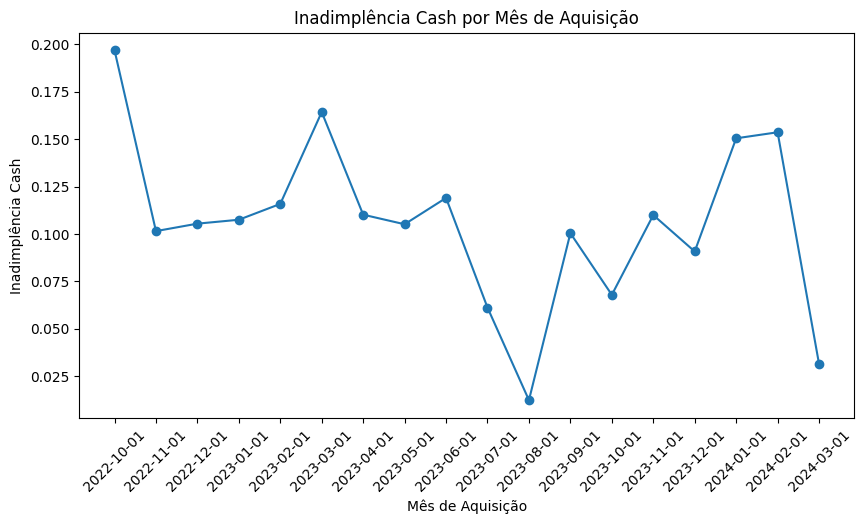

In [34]:
# Plotando o grafico para visualizar
plt.figure(figsize=(10,5))
plt.plot(inad_mes["mes_aquisicao"], inad_mes["inad_cash"], marker="o")

plt.title("Inadimplência Cash por Mês de Aquisição")
plt.xlabel("Mês de Aquisição")
plt.ylabel("Inadimplência Cash")
plt.xticks(rotation=45)

plt.show()

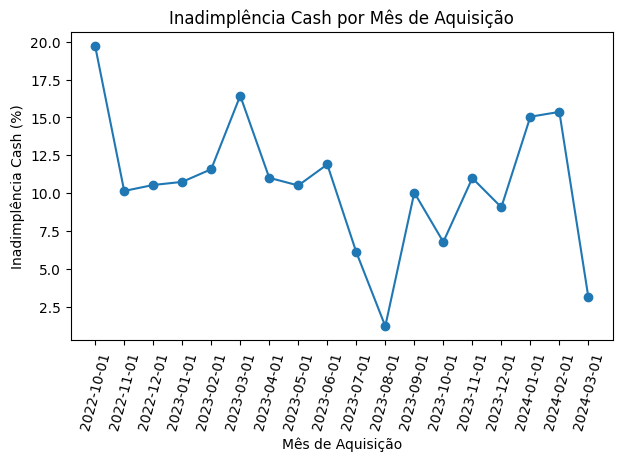

In [44]:
# Plot para colocar no slide
plt.figure(figsize=(7,4))
plt.plot(inad_mes["mes_aquisicao"], inad_mes["inad_cash"] * 100, marker="o")

plt.title("Inadimplência Cash por Mês de Aquisição")
plt.xlabel("Mês de Aquisição")
plt.ylabel("Inadimplência Cash (%)")
plt.xticks(rotation=75)

plt.show()

In [35]:
# Agora, inadimplencia por convenio
inad_convenio = (1 - (df_vencidas.groupby("id_convenio")["valor_pago"].sum() / 
                      df_vencidas.groupby("id_convenio")["valor_parcela"].sum())).reset_index(name="inad_cash")

inad_convenio = inad_convenio.sort_values("inad_cash", ascending=False)
inad_convenio

,id_convenio,inad_cash
2,3,0.194705
9,10,0.188843
1,2,0.086798
10,11,0.072984
5,6,0.054397
7,8,0.044374
0,1,0.042887
8,9,0.038627
3,4,0.031883
4,5,0.012440


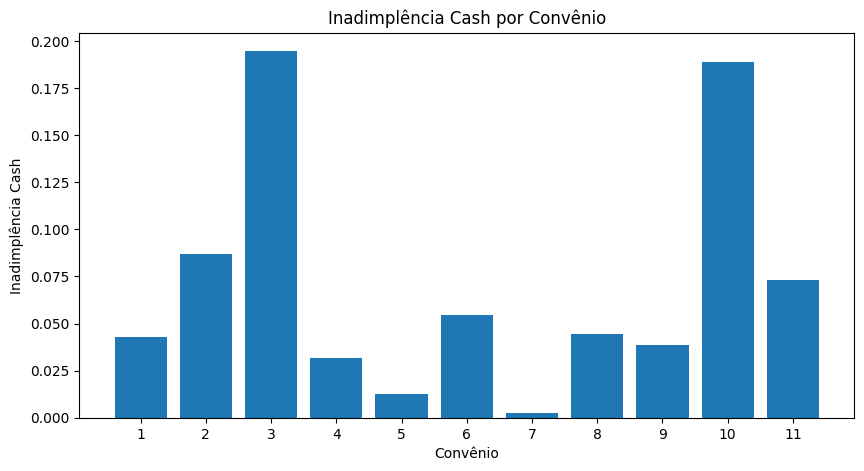

In [36]:
# Plotando
plt.figure(figsize=(10,5))
plt.bar(inad_convenio["id_convenio"], inad_convenio["inad_cash"])

plt.title("Inadimplência Cash por Convênio")
plt.xlabel("Convênio")
plt.ylabel("Inadimplência Cash")
plt.xticks(inad_convenio["id_convenio"])

plt.show()

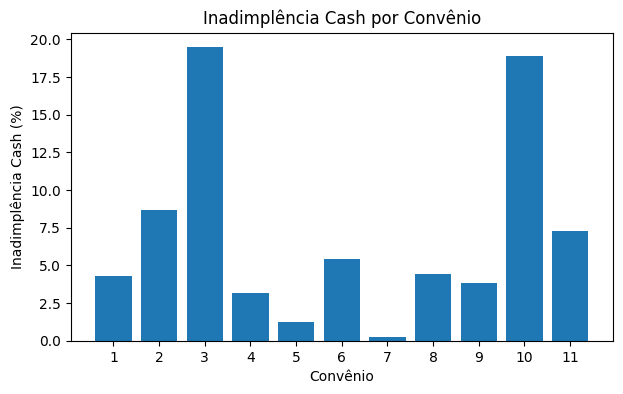

In [43]:
# Plot para colocar no slide
plt.figure(figsize=(7,4))
plt.bar(inad_convenio["id_convenio"], inad_convenio["inad_cash"] * 100)

plt.title("Inadimplência Cash por Convênio")
plt.xlabel("Convênio")
plt.ylabel("Inadimplência Cash (%)")
plt.xticks(inad_convenio["id_convenio"])

plt.show()

In [37]:
# Por mes de vencimento
inad_venc = (1 - (df_vencidas.groupby("mes_vencimento")["valor_pago"].sum() 
                  / df_vencidas.groupby("mes_vencimento")["valor_parcela"].sum())).reset_index(name="inad_cash")

inad_venc = inad_venc.sort_values("mes_vencimento")
inad_venc

,mes_vencimento,inad_cash
0,2022-11-30,0.000000e+00
1,2022-12-31,0.000000e+00
2,2023-01-31,0.000000e+00
3,2023-02-28,6.916654e-08
4,2023-03-31,3.314592e-07
5,2023-04-30,8.131295e-07
6,2023-05-31,7.341639e-03
7,2023-06-30,3.373308e-02
8,2023-07-31,1.631381e-02
9,2023-08-31,2.843697e-02


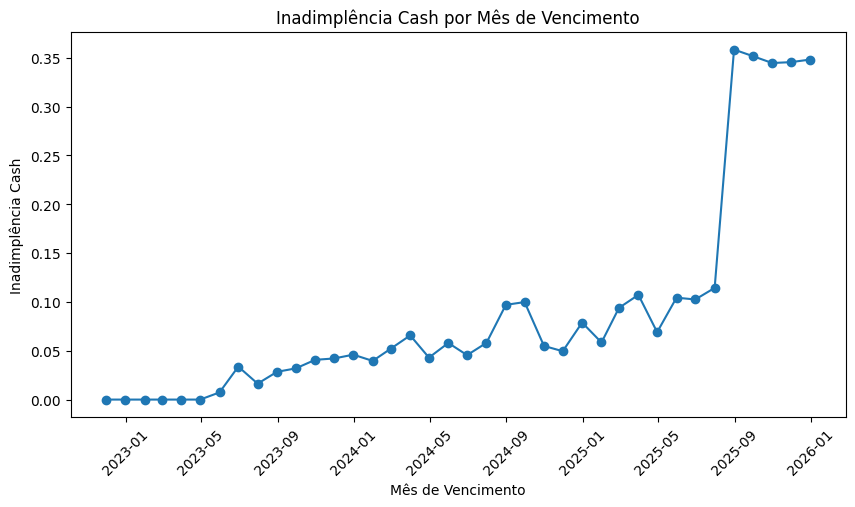

In [38]:
# Plotando o grafico
plt.figure(figsize=(10,5))
plt.plot(inad_venc["mes_vencimento"], inad_venc["inad_cash"], marker="o")

plt.title("Inadimplência Cash por Mês de Vencimento")
plt.xlabel("Mês de Vencimento")
plt.ylabel("Inadimplência Cash")
plt.xticks(rotation=45)

plt.show()

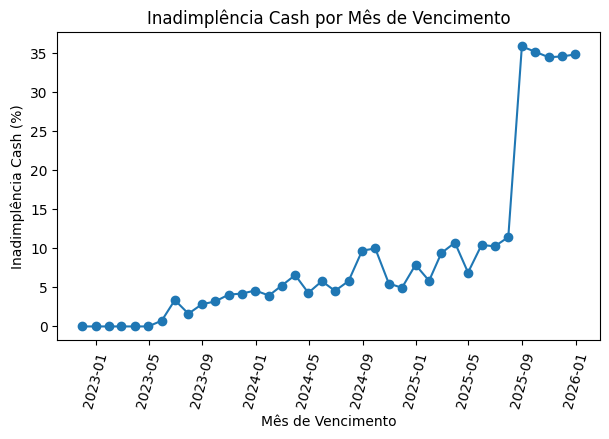

In [47]:
# Plor para colocar no slide
plt.figure(figsize=(7,4))
plt.plot(inad_venc["mes_vencimento"], inad_venc["inad_cash"] * 100, marker="o")

plt.title("Inadimplência Cash por Mês de Vencimento")
plt.xlabel("Mês de Vencimento")
plt.ylabel("Inadimplência Cash (%)")
plt.xticks(rotation=75)

plt.show()